In [1]:
# Importa as bibliotecas usadas
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import curve_fit
from astropy.cosmology import Planck15
from matplotlib import pyplot as plt
#plt.rcParams["text.usetex"] = True

import bagpipes as pipes

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


### Lendo os dados do catálogo:

In [57]:
snap_to_z = pd.read_pickle('snap_to_z.pkl')
#etg_table = pd.read_pickle('mergers_ETGs.pkl')
etg_table = pd.read_pickle('catalogue_ETGs.pkl')

table_massformed = np.array(etg_table['mass'])
table_SFR = np.array(etg_table['SFR'])
table_sSFR = np.array(etg_table['sSFR'])
table_met = np.array(etg_table['metallicity'])
table_dispvel = np.array(etg_table['dispvel'])

#U, B, V, K, g, r, i, z
table_photometrics = np.array([etg_table['U'], etg_table['B'], etg_table['V'], etg_table['K'], 
                            etg_table['g'], etg_table['r'], etg_table['i'], etg_table['z']]).T

trees = np.array(etg_table['tree'])

In [58]:
num_gal = len(table_massformed)
num_gal

3619

#### Diagrama Cor-Magnitude e Cor-Cor TNG vs SPLUS:

In [ ]:
# Lendo dados do SPLUS
splus_data = pd.read_csv("splusmorph.csv")

# Selecionando dados apenas de ETGs
filtered_etgs = splus_data[(splus_data["probetg"] > 0.9) & (splus_data["u_auto"] < 30) & (splus_data["g_auto"] < 30) & (splus_data["r_auto"] < 30)]

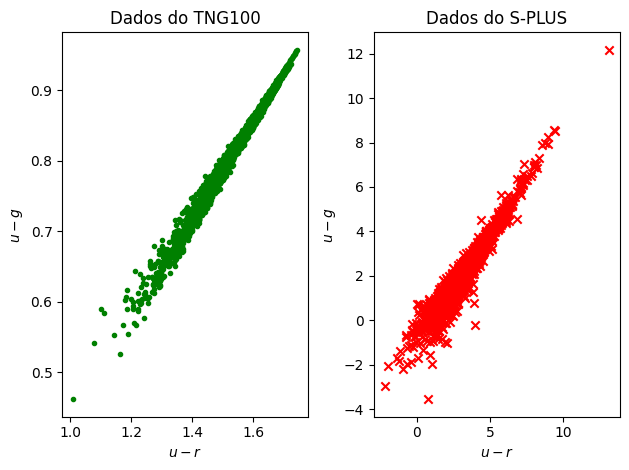

In [71]:
plt.subplot(1, 2, 1)
plt.scatter(etg_table['U'] - etg_table['r'], etg_table['U'] - etg_table['g'], 
            c="green", marker=".")
plt.xlabel(r"$u - r$")
plt.ylabel(r"$u - g$")
plt.title("Dados do TNG100")

plt.subplot(1, 2, 2)
plt.scatter(filtered_etgs['u_auto'] - filtered_etgs['r_auto'], filtered_etgs['u_auto'] - filtered_etgs['g_auto'],
            c="red", marker="x")
plt.xlabel(r"$u - r$")
plt.ylabel(r"$u - g$")
plt.title("Dados do S-PLUS")

plt.tight_layout()
plt.show()

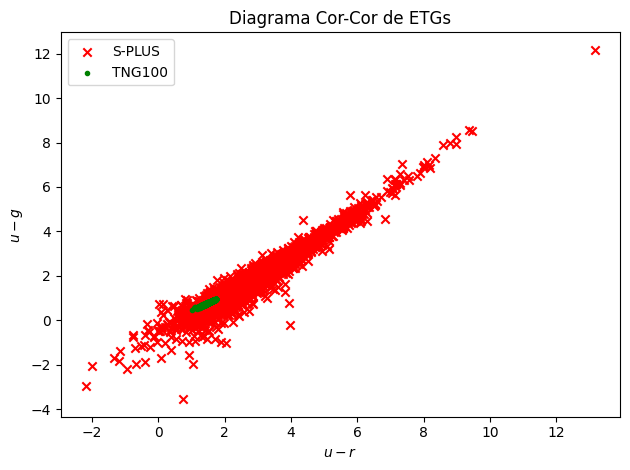

In [ ]:
plt.scatter(filtered_etgs['u_auto'] - filtered_etgs['r_auto'], filtered_etgs['u_auto'] - filtered_etgs['g_auto'],
            c="red", marker="x", label="S-PLUS")

plt.scatter(etg_table['U'] - etg_table['r'], etg_table['U'] - etg_table['g'], 
            c="green", marker=".", label="TNG100")

plt.xlabel(r"$u - r$")
plt.ylabel(r"$u - g$")

plt.title("Diagrama Cor-Cor de ETGs")
plt.legend()
plt.tight_layout()
plt.show()

### Estimação dos dados:

In [4]:
def dbplaw(t, A, tau, alpha, beta):
    return A*((t/tau)**alpha + (t/tau)**-beta)**-1

/tmp/ipykernel_14190/2749534632.py:2: RuntimeWarning: overflow encountered in power
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1


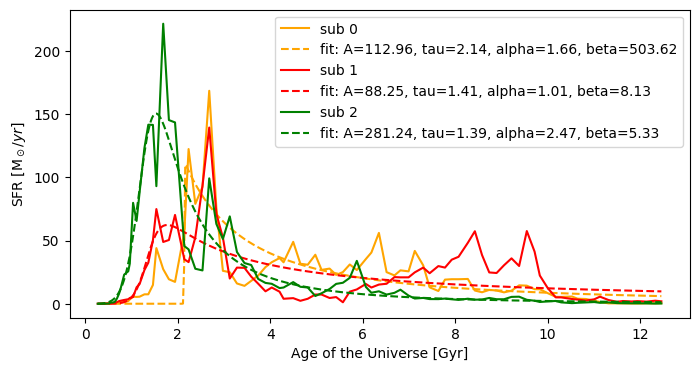

In [5]:
fig = plt.figure(figsize=(8,4))

colors = ['orange', 'red', 'green']
for i in range(0, 3):
    tree = trees[i]
    
    ages = []
    for num in tree['SnapNum']:
        redshift = snap_to_z["redshift"][num]
        universe_age = Planck15.age(redshift).value
        if universe_age == 0: universe_age = 1e-6
        ages.append(universe_age)
    
    ages = np.array(ages)
    sfr_data = tree['SubhaloSFR']
    
    # Plota os dados originais
    plt.plot(ages, sfr_data, '-', c=colors[i % 3], label='sub %d' % i)
    
    xdata = np.linspace(min(ages), max(ages), 500)

    initial_guesses = [max(sfr_data), np.median(ages), 2, 2]
    popt, pcov = curve_fit(dbplaw, ages, sfr_data, p0=initial_guesses, maxfev=20000)
    
    plt.plot(xdata, dbplaw(xdata, *popt), '--', c=colors[i % 3],
            label='fit: A=%.2f, tau=%.2f, alpha=%.2f, beta=%.2f' % tuple(popt))
    
    
plt.xlabel('Age of the Universe [Gyr]')
plt.ylabel('SFR [M$_\odot / yr$]')
plt.legend();

In [6]:
tau = np.zeros(num_gal)
alpha = np.zeros(num_gal)
beta = np.zeros(num_gal)

for i in range(num_gal):
    tree = trees[i]
    
    ages = []
    for num in tree['SnapNum']:
        redshift = snap_to_z["redshift"][num]
        universe_age = Planck15.age(redshift).value
        if universe_age == 0: universe_age = 1e-6
        ages.append(universe_age)
    
    ages = np.array(ages)
    sfr_data = tree['SubhaloSFR']
    
    try:
        initial_guesses = [max(sfr_data), np.median(ages), 5, 0.01]
        popt, pcov = curve_fit(dbplaw, ages, sfr_data, p0=initial_guesses, maxfev=100000)
        
        tau[i] = popt[1]
        alpha[i] = popt[2]
        beta[i] = popt[3]
    except: 
        print(f"Subhalo {i} não convergiu.")
        tau[i] = -1

tree_df = pd.DataFrame()
tree_df['tau'] = tau
tree_df['alpha'] = alpha
tree_df['beta'] = beta

#tree_df.to_csv('merger_estimated.csv', index=False)
tree_df.to_csv('catalogue_estimated.csv', index=False)

/tmp/ipykernel_14190/2749534632.py:2: RuntimeWarning: overflow encountered in power
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1
/tmp/ipykernel_14190/2749534632.py:2: RuntimeWarning: invalid value encountered in power
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1
/tmp/ipykernel_14190/2681156422.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(dbplaw, ages, sfr_data, p0=initial_guesses, maxfev=100000)


In [14]:
#merger_data = pd.read_csv('merger_estimated.csv')
merger_data = pd.read_csv('catalogue_estimated.csv')
tau = np.array(merger_data['tau'])
alpha = np.array(merger_data['alpha'])
beta = np.array(merger_data['beta'])

tree_mask = (tau != -1) & (alpha < 1000) & (beta < 1000) \
            & (alpha > 0) & (beta > 0) & (tau > 1e-2)

etg_met = table_met[tree_mask]
etg_massformed = table_massformed[tree_mask]
etg_SFR = table_SFR[tree_mask]
etg_dispvel = table_dispvel[tree_mask]
alpha = alpha[tree_mask]
beta = beta[tree_mask]
tau = tau[tree_mask]

In [15]:
# Estimamos a função de densidade de probabilidade multivariada com o KDE
values = np.vstack([etg_met, np.log10(etg_massformed), etg_SFR, 
                    np.log10(etg_dispvel), np.log10(tau), np.log10(alpha), np.log10(beta)])
kernel = stats.gaussian_kde(values, bw_method='silverman')

### Plots dos resultados:

In [16]:
subplot_pos = 420

# Pega dados aleatórios baseados na distribuição original
def plot_mock(mock_data, data, name):
    global subplot_pos
    
    subplot_pos += 1
    plt.subplot(subplot_pos)
    plt.hist(data, bins=60, color='blue', alpha=0.7)
    plt.xlabel(name)
    plt.ylabel("Contagem")
    if (subplot_pos - 1) % 10 == 0: plt.title(f"Dados do TNG")
    
    subplot_pos += 1
    plt.subplot(subplot_pos)
    plt.hist(mock_data, bins=60, color='orange', alpha=0.7)
    plt.xlabel(name)
    if (subplot_pos - 2) % 10 == 0: plt.title(f"Dados randomizados")
    
# Reamostragem dos dados
mock_data = kernel.resample(10000)

mock_SFR = (mock_data[2, :])[mock_data[2, :] >= 0]
sfr_mask = (mock_data[2, :] >= 0)

mock_met = mock_data[0, :][sfr_mask]
mock_mass = (mock_data[1, :])[sfr_mask]
mock_dispvel = 10**(mock_data[3, :])[sfr_mask]

mock_tau = 10**(mock_data[4, :])[sfr_mask]
mock_alpha = 10**(mock_data[5, :])[sfr_mask]
mock_beta = 10**(mock_data[6, :])[sfr_mask]

# Plot das figuras
fig = plt.figure(figsize=(14, 12))

plot_mock(mock_met, etg_met, r"Metalicidade $(\log{(Z/Z_{\odot})})$")
plot_mock(mock_mass, np.log10(etg_massformed), r"$\log{}$(Massa)")
plot_mock(mock_SFR, etg_SFR, r"SFR $(M_{\odot} / yr)$")
plot_mock(mock_dispvel, etg_dispvel, r"Dispersão de Velocidade $(km/s)$")

plt.tight_layout()
plt.show()

# Plot da figura dos parametros da SFH
fig = plt.figure(figsize=(14, 12))
subplot_pos = 320

plot_mock(np.log10(mock_tau), np.log10(tau), r"$\log(\tau)$")
plot_mock(np.log10(mock_alpha), np.log10(alpha), r"$\log(\alpha)$")
plot_mock(np.log10(mock_beta), np.log10(beta), r"$\log(\beta)$")

plt.tight_layout()
plt.show()

RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (TeX Live 2026/Arch Linux) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(/usr/share/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(/usr/share/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texmf-dist/tex/latex/type1cm/type1cm.sty)

! LaTeX Error: File `type1ec.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.8 \usepackage
               [utf8]{inputenc}^^M
No pages of output.
Transcript written on file.log.




Error in callback <function _draw_all_if_interactive at 0x7f9dd7233520> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (TeX Live 2026/Arch Linux) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(/usr/share/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(/usr/share/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texmf-dist/tex/latex/type1cm/type1cm.sty)

! LaTeX Error: File `type1ec.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.8 \usepackage
               [utf8]{inputenc}^^M
No pages of output.
Transcript written on file.log.




RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (TeX Live 2026/Arch Linux) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(/usr/share/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(/usr/share/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texmf-dist/tex/latex/type1cm/type1cm.sty)

! LaTeX Error: File `type1ec.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.8 \usepackage
               [utf8]{inputenc}^^M
No pages of output.
Transcript written on file.log.




<Figure size 1400x1200 with 8 Axes>

In [10]:
len(mock_SFR)

6616

Massa: 10.958965451582133 
Metalicidade: 0.11149961281328119 
Dispersão de Velocidade: 135.6348346855064


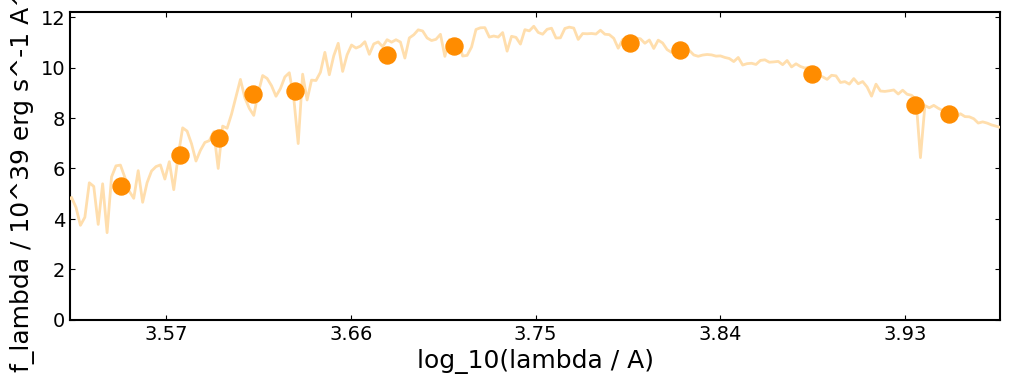

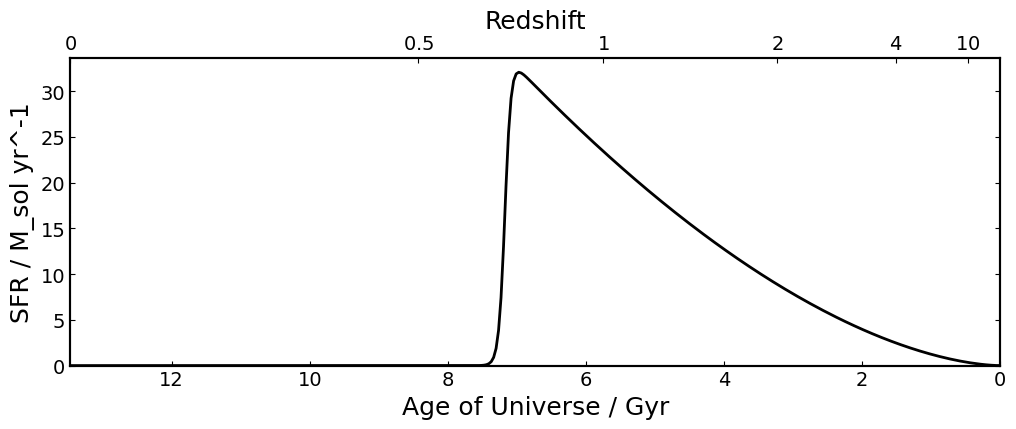

Massa: 10.807213547838831 
Metalicidade: 0.05233016773106043 
Dispersão de Velocidade: 127.17168626272058


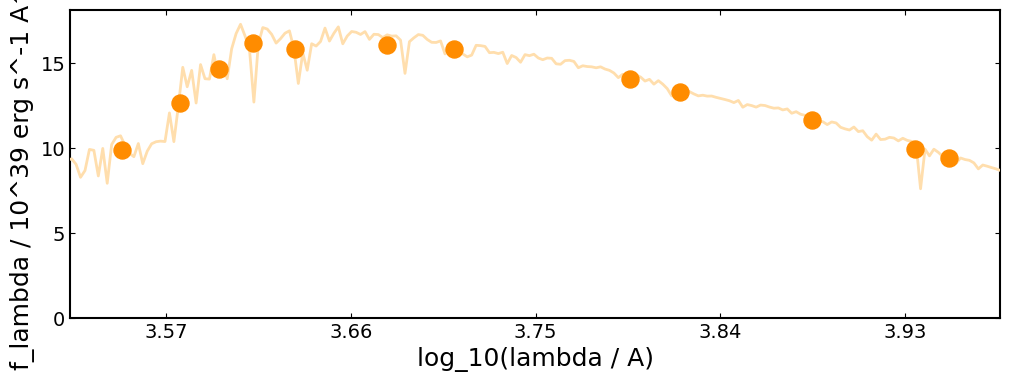

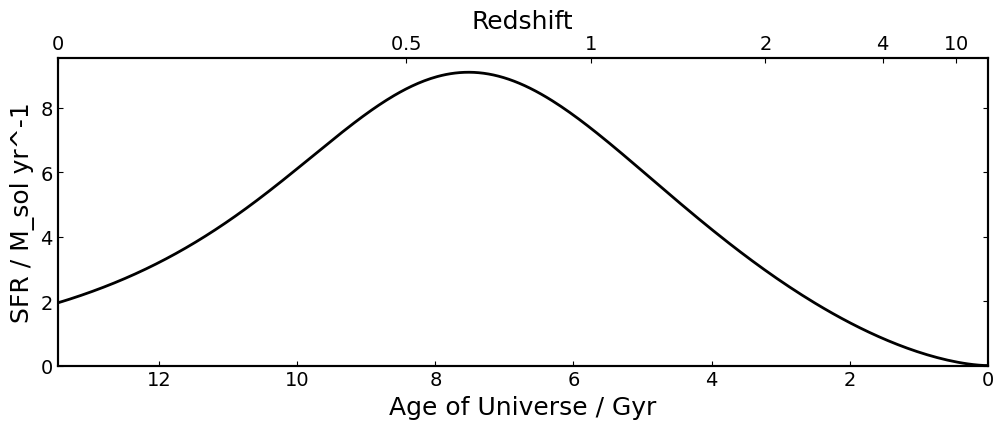

Massa: 10.829199173169558 
Metalicidade: 0.022339678578763948 
Dispersão de Velocidade: 141.47408477881405


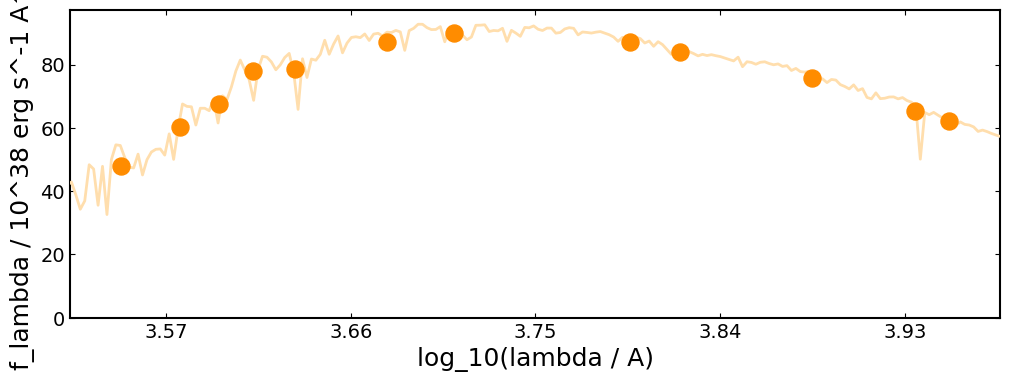

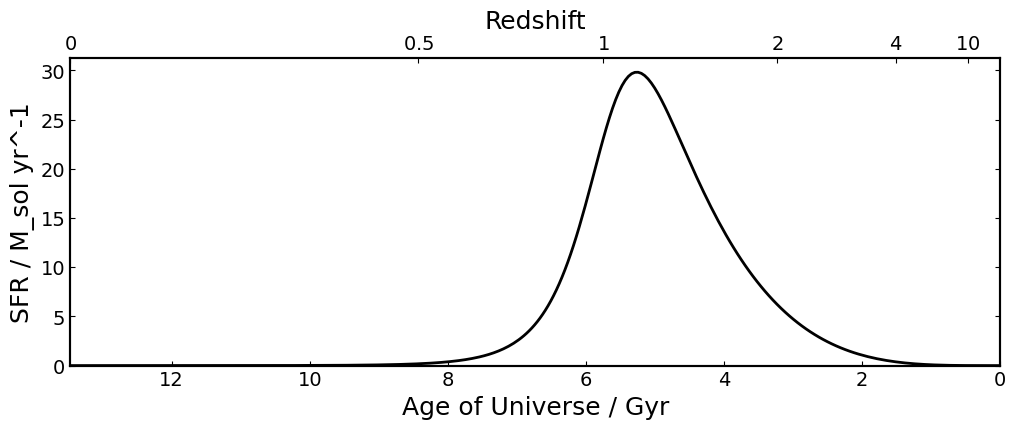

Massa: 11.14325114806088 
Metalicidade: 0.043686326520276784 
Dispersão de Velocidade: 164.8083219783639


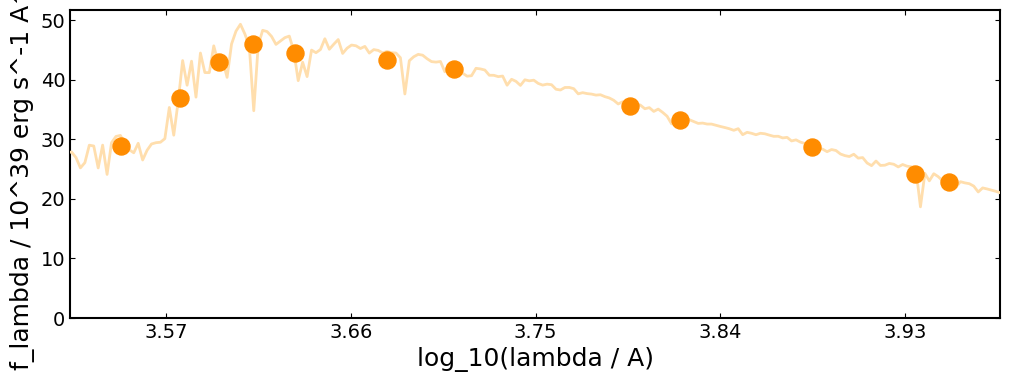

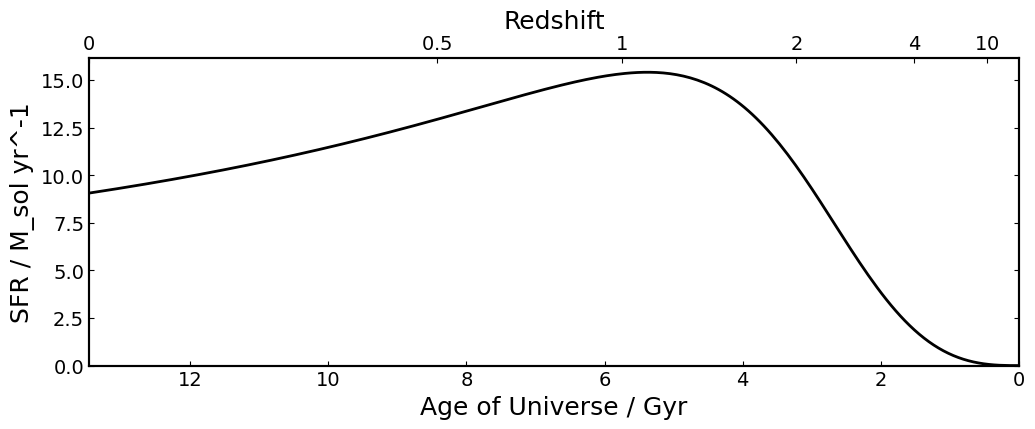

Massa: 11.010236378740249 
Metalicidade: 0.05195073193141988 
Dispersão de Velocidade: 171.83969980349667


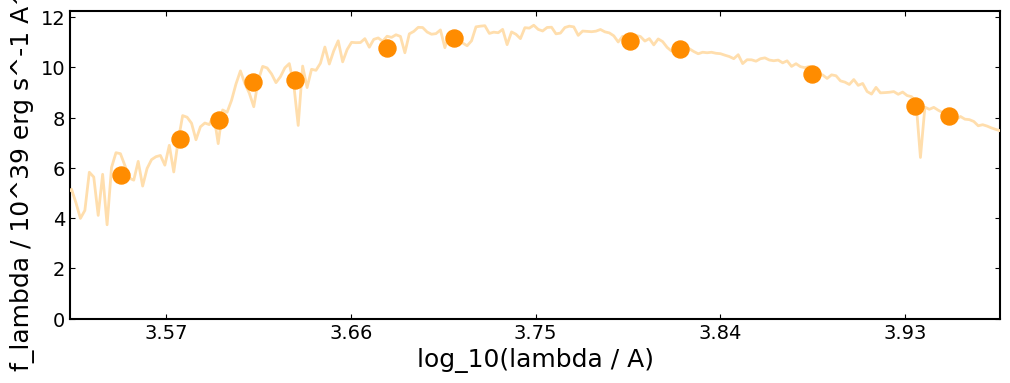

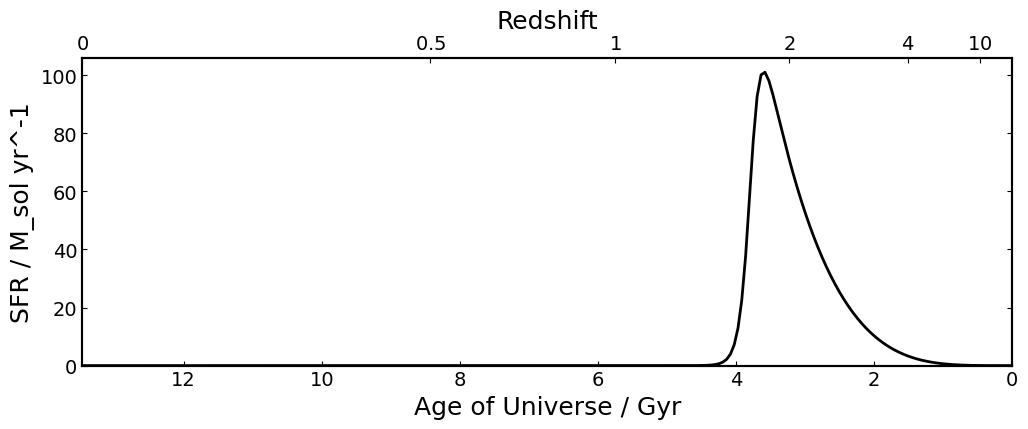

In [11]:
from numpy import random as rnd

total_samples = 5

# gera os modelos do bagpipes randomizados de acordo com as PDFs
for i in range(total_samples):
    index = rnd.randint(0, len(mock_SFR))

    metallicity = mock_met[index]
    mass = mock_mass[index]
    dispvel = mock_dispvel[index]
    tau_mock = mock_tau[index]
    alpha_mock = mock_alpha[index]
    beta_mock = mock_beta[index]
    
    print("Massa:", mass, "\nMetalicidade:", metallicity, "\nDispersão de Velocidade:", dispvel)
    
    dblplaw = {}
    dblplaw["massformed"] = mass
    dblplaw["metallicity"] = metallicity

    dblplaw["alpha"] = alpha_mock
    dblplaw["beta"] = beta_mock
    dblplaw["tau"] = tau_mock

    dust = {}
    dust["type"] = "Calzetti"
    dust["Av"] = 0.3
    dust["eta"] = 3

    model_components = {}
    model_components["dblplaw"] = dblplaw
    model_components["dust"] = dust
    model_components["redshift"] = 0 # redshift observado
    model_components["t_bc"] = 0.01 # idade máxima da nuvem molecular de uma população jovem
    model_components["veldisp"] = dispvel # dispersao de velocidade em km/s

    filt_list = np.loadtxt("splus-filters/splus_filters.txt", dtype="str")

    model = pipes.model_galaxy(model_components, filt_list=filt_list)
    #model.photometry
    model.plot()
    model.sfh.plot()